# 1. Feature Engineering (Test on 1 stock)

### Import Data

In [86]:
from pathlib import Path
import sys
import pandas as pd

# Add src as part of the import system also
sys.path.append(str(Path.cwd().parent / 'src'))

from config import RAW_DATA_PATH

df = pd.read_csv(RAW_DATA_PATH / 'all_stocks_combined.csv')

df['Date'] = pd.to_datetime(df['Date'])

### Quick Check

In [87]:
df.head()

,Date,Close,High,Low,Open,Volume,Ticker,Name
0,2018-01-02,5.563982,5.575502,5.523663,5.558222,5284100,1155.KL,Maybank
1,2018-01-03,5.633099,5.633099,5.563981,5.563981,13946300,1155.KL,Maybank
2,2018-01-04,5.644620,5.656140,5.633101,5.633101,18711500,1155.KL,Maybank
3,2018-01-05,5.644620,5.656140,5.638860,5.644620,17266600,1155.KL,Maybank
4,2018-01-08,5.673419,5.673419,5.638859,5.644619,19238800,1155.KL,Maybank


In [88]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25227 entries, 0 to 25226
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    25227 non-null  datetime64[us]
 1   Close   25227 non-null  float64       
 2   High    25227 non-null  float64       
 3   Low     25227 non-null  float64       
 4   Open    25227 non-null  float64       
 5   Volume  25227 non-null  int64         
 6   Ticker  25227 non-null  str           
 7   Name    25227 non-null  str           
dtypes: datetime64[us](1), float64(4), int64(1), str(2)
memory usage: 1.9 MB


In [89]:
df['Ticker'].unique()

<ArrowStringArray>
['1155.KL', '1295.KL', '1023.KL', '1066.KL', '5819.KL', '1015.KL', '2488.KL',
 '5185.KL', '5258.KL',  'D05.SI',  'O39.SI',  'U11.SI']
Length: 12, dtype: str

In [90]:
df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
Ticker    0
Name      0
dtype: int64

### Testing Visualization

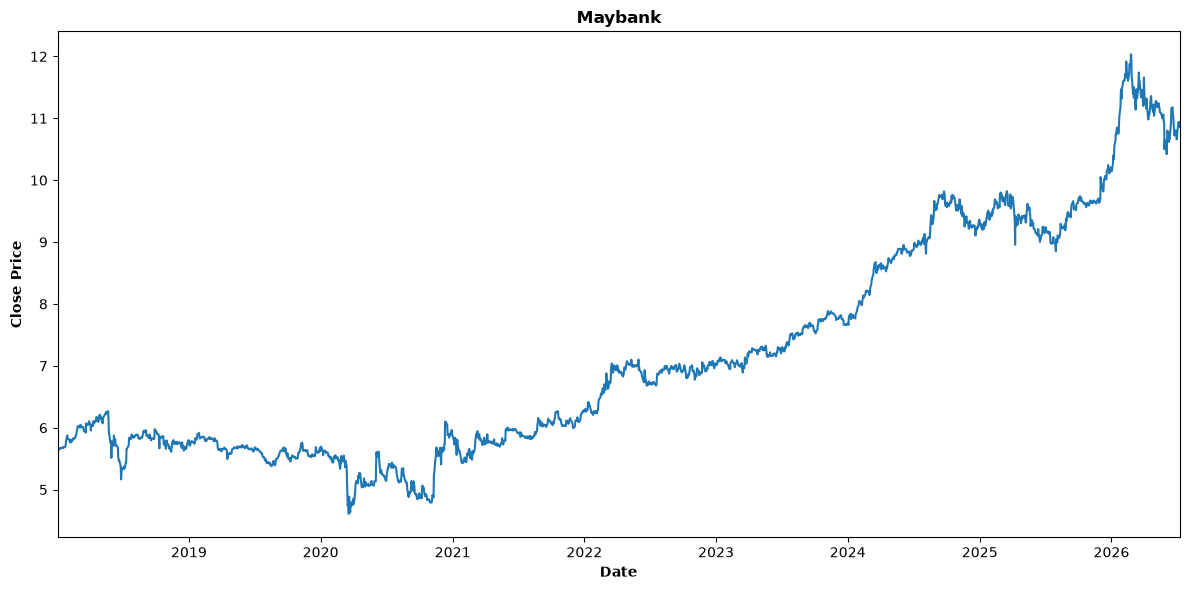

In [91]:
import matplotlib.pyplot as plt

maybank = df[df['Ticker'] == '1155.KL'].copy()

plt.figure(figsize=(12,6))

plt.plot(maybank['Date'], maybank['Close'])

plt.title('Maybank', fontweight = 'bold')
plt.xlabel('Date', fontweight = 'bold')
plt.ylabel('Close Price', fontweight = 'bold')

plt.xlim(maybank['Date'].min(), maybank['Date'].max()) # restricting the range

plt.tight_layout()
plt.show()

### Features (Basics)

#### Returns

In [92]:
maybank['returns'] = maybank['Close'].pct_change()

maybank['returns'].head()

0         NaN
1    0.012422
2    0.002045
3    0.000000
4    0.005102
Name: returns, dtype: float64

- Returns is calculated by current row vs previous row.
- Row 0 is NaN (correct because it doesn't have previous row)

#### Simple Moving Average (SMA)

In [93]:
maybank['sma_20'] = maybank['Close'].rolling(window = 20).mean()
maybank['sma_50'] = maybank['Close'].rolling(window = 50).mean()

maybank[['Date', 'Close', 'sma_20', 'sma_50']].tail()

,Date,Close,sma_20,sma_50
2084,2026-07-06,10.94,10.833,10.9460
2085,2026-07-07,10.92,10.844,10.9400
2086,2026-07-08,10.94,10.860,10.9356
2087,2026-07-09,10.86,10.869,10.9308
2088,2026-07-10,10.90,10.881,10.9244


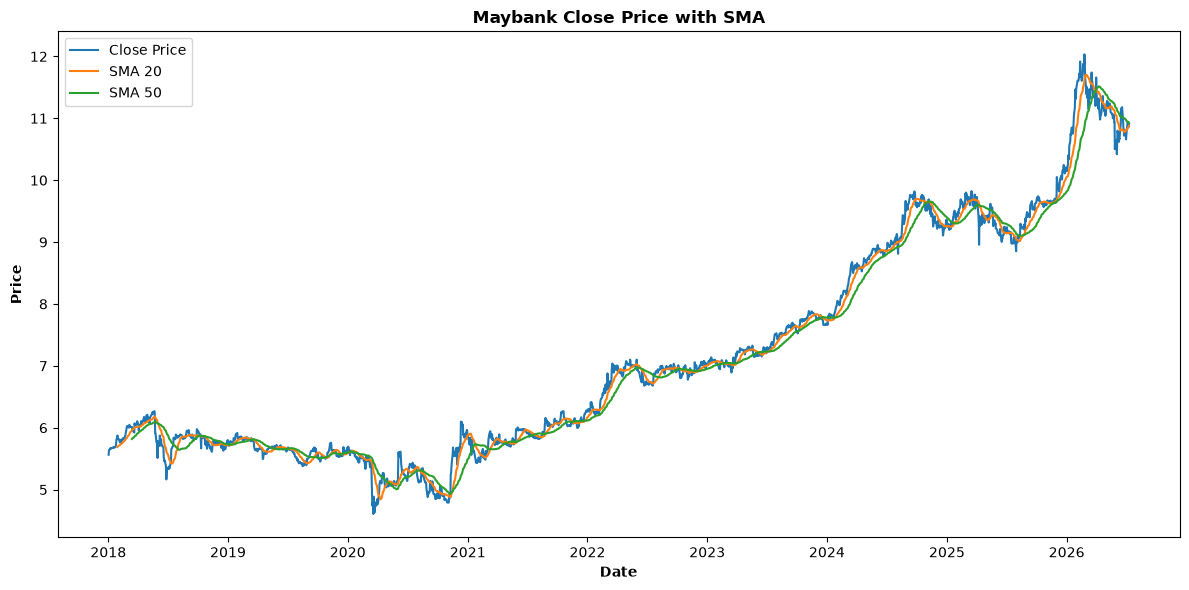

In [94]:
plt.figure(figsize=(12,6))

plt.plot(maybank['Date'], maybank['Close'], label = 'Close Price')
plt.plot(maybank['Date'], maybank['sma_20'], label = 'SMA 20')
plt.plot(maybank['Date'], maybank['sma_50'], label = 'SMA 50')

plt.title('Maybank Close Price with SMA', fontweight = 'bold')
plt.xlabel('Date', fontweight = 'bold')
plt.ylabel('Price', fontweight = 'bold')
plt.legend()

plt.tight_layout()
plt.show()

- SMA_20 calculates 20 days simple moving average of the closing price.
- SMA_50 calculates 50 days simple moving average of the closing price.
- Therefore, the close price is the most volatile, SMA_20 is smoother, and SMA_50 is the smoothest.
- The plot confirms that they are calculated correctly.

*Note: SMA = all past prices equal weight*

#### Exponential Moving Average (EMA)

In [95]:
maybank['ema_20'] = maybank['Close'].ewm(span=20, adjust=False).mean()
maybank['ema_50'] = maybank['Close'].ewm(span=50, adjust=False).mean()

maybank[['Date', 'Close', 'ema_20', 'ema_50']].head()

,Date,Close,ema_20,ema_50
0,2018-01-02,5.563982,5.563982,5.563982
1,2018-01-03,5.633099,5.570565,5.566692
2,2018-01-04,5.644620,5.577618,5.569748
3,2018-01-05,5.644620,5.583999,5.572685
4,2018-01-08,5.673419,5.592515,5.576635


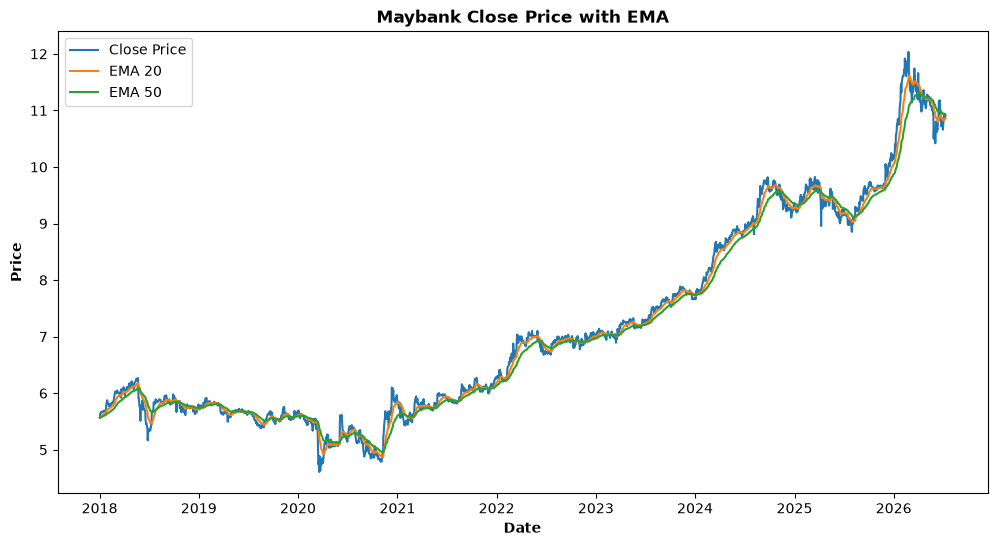

In [96]:
plt.figure(figsize=(12,6))

plt.plot(maybank['Date'], maybank['Close'], label = 'Close Price')
plt.plot(maybank['Date'], maybank['ema_20'], label = 'EMA 20')
plt.plot(maybank['Date'], maybank['ema_50'], label = 'EMA 50')

plt.title('Maybank Close Price with EMA', fontweight = 'bold')
plt.xlabel('Date', fontweight = 'bold')
plt.ylabel('Price', fontweight = 'bold')

plt.legend()
plt.show()

- EMA_20 calculates 20 days exponential moving average which is giving higher weight to recent prices.
- EMA_50 calculates 50 days exponential moving average which is capturing a longer term trend with more responsiveness than SMA.
- EMA_20 follows price movements more closely, while EMA_50 provides a smoother long term trend indicator.
- The plot confirms that they are calculated correctly.

*Note: EMA = more recent prices matter more*

#### Volume Feature

In [97]:
maybank['volume_sma_20'] = maybank['Volume'].rolling(20).mean()

In [98]:
maybank[['Date', 'Close', 'volume_sma_20']].tail()

,Date,Close,volume_sma_20
2084,2026-07-06,10.94,10284660.0
2085,2026-07-07,10.92,10075995.0
2086,2026-07-08,10.94,9253515.0
2087,2026-07-09,10.86,8896935.0
2088,2026-07-10,10.90,8695125.0


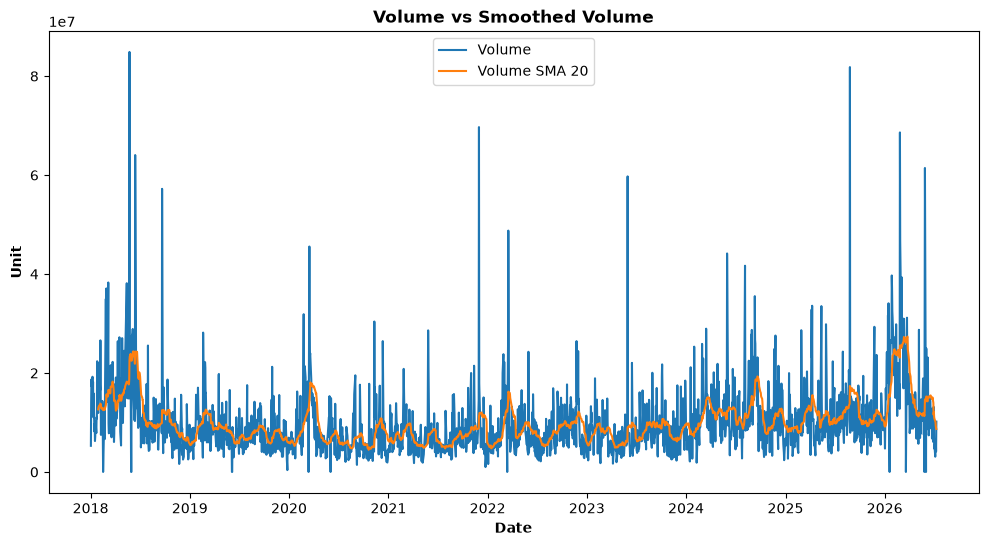

In [99]:
plt.figure(figsize=(12,6))

plt.plot(maybank['Date'], maybank['Volume'], label = 'Volume')
plt.plot(maybank['Date'], maybank['volume_sma_20'], label = 'Volume SMA 20')

plt.title('Volume vs Smoothed Volume', fontweight = 'bold')
plt.xlabel('Date', fontweight = 'bold')
plt.ylabel('Unit', fontweight = 'bold')

plt.legend()
plt.show()

- Smooths trading activity.
- Helps to detect unusual volume spikes.
- Plot looks correct.

### Features (Technical Indicators)

#### Relative Strength Index (RSI)

In [100]:
import pandas_ta as ta

maybank['rsi'] = ta.rsi(maybank['Close'], length = 14) # look back last 14 days

In [101]:
maybank[['Date', 'Close', 'rsi']].head(20)

,Date,Close,rsi
0,2018-01-02,5.563982,NaN
1,2018-01-03,5.633099,100.000000
2,2018-01-04,5.644620,100.000000
3,2018-01-05,5.644620,100.000000
4,2018-01-08,5.673419,100.000000
5,2018-01-09,5.661899,98.497846
6,2018-01-10,5.667659,98.509899
7,2018-01-11,5.667659,98.509899
8,2018-01-12,5.673419,98.523637
9,2018-01-15,5.673419,98.523637


*Note: pandas-ta uses **Wilder’s smoothing (RMA)**: Starts building averages gradually which means it doesn't wait for a full 14-day block like a rolling mean. Therefore NaNs will be lesser instead of what we expected from textbook RSI (having 14 NaNs)*

In [102]:
maybank['rsi'].describe()

count    2088.000000
mean       53.845859
std        12.310743
min        17.760791
25%        45.429517
50%        53.210392
75%        61.557353
max       100.000000
Name: rsi, dtype: float64

**RSI meaning:**

- 0–30 → oversold (too cheap, may bounce up)
- 30–70 → normal zone
- 70–100 → overbought (too expensive, may drop)

*Note: Must be 0-100, describe above confirms that*
   

#### Momentum Trend Indicator (MACD)

In [103]:
#12, 26, and 9 are the standard, textbook defaults introduced by Gerald Appel
maybank['macd'] = ta.macd(maybank['Close'])['MACD_12_26_9']
maybank['macd_signal'] = ta.macd(maybank['Close'])['MACDs_12_26_9']
maybank['macd_diff'] = ta.macd(maybank['Close'])['MACDh_12_26_9']

In [104]:
maybank[['Date','macd','macd_signal','macd_diff']].tail(10)

,Date,macd,macd_signal,macd_diff
2079,2026-06-29,-0.031898,-0.036710,0.004812
2080,2026-06-30,-0.035076,-0.036383,0.001307
2081,2026-07-01,-0.046740,-0.038454,-0.008285
2082,2026-07-02,-0.048963,-0.040556,-0.008407
2083,2026-07-03,-0.045361,-0.041517,-0.003844
2084,2026-07-06,-0.030853,-0.039384,0.008531
2085,2026-07-07,-0.020731,-0.035654,0.014923
2086,2026-07-08,-0.010969,-0.030717,0.019748
2087,2026-07-09,-0.009577,-0.026489,0.016912
2088,2026-07-10,-0.005187,-0.022228,0.017042


**MACD meaning:**

- MACD > signal → bullish momentum
- MACD < signal → bearish momentum
- Diff = strength of movement

*Note: MACD values fluctuate around zero. Correct*

#### Bollinger Bands

In [105]:
bb = ta.bbands(maybank['Close'], length=20)

maybank['bb_low'] = bb['BBL_20_2.0_2.0']
maybank['bb_mid'] = bb['BBM_20_2.0_2.0']
maybank['bb_high'] = bb['BBU_20_2.0_2.0']

In [106]:
maybank[['Close', 'bb_low', 'bb_mid', 'bb_high']].tail(10)

,Close,bb_low,bb_mid,bb_high
2079,10.80,10.389607,10.792,11.194393
2080,10.78,10.402919,10.799,11.195081
2081,10.66,10.405512,10.800,11.194488
2082,10.74,10.462587,10.816,11.169413
2083,10.80,10.487309,10.826,11.164691
2084,10.94,10.490803,10.833,11.175197
2085,10.92,10.505682,10.844,11.182318
2086,10.94,10.536337,10.860,11.183663
2087,10.86,10.556597,10.869,11.181403
2088,10.90,10.584359,10.881,11.177641


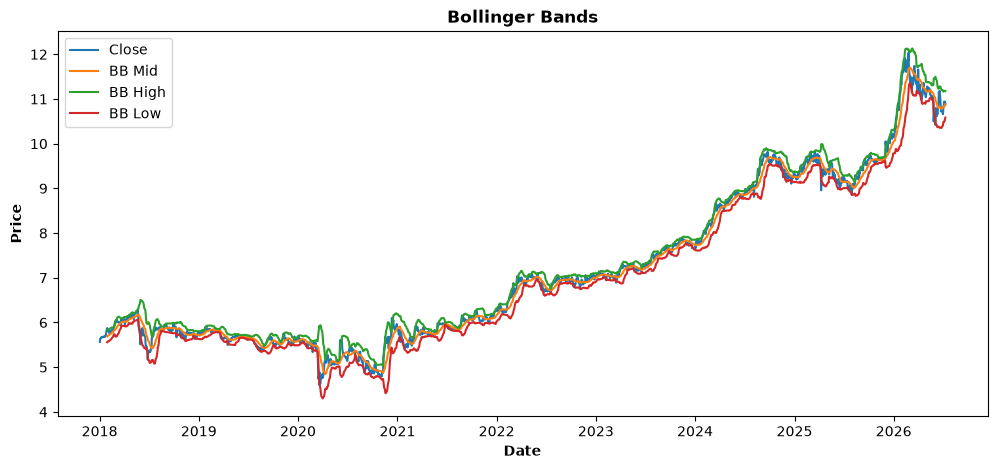

In [107]:
plt.figure(figsize=(12,5))

plt.plot(maybank['Date'], maybank['Close'], label = 'Close')
plt.plot(maybank['Date'], maybank['bb_mid'], label = 'BB Mid')
plt.plot(maybank['Date'], maybank['bb_high'], label = 'BB High')
plt.plot(maybank['Date'], maybank['bb_low'], label = 'BB Low')

plt.title('Bollinger Bands', fontweight = 'bold')
plt.xlabel('Date', fontweight = 'bold')
plt.ylabel('Price', fontweight = 'bold')

plt.legend()
plt.show()

**BB meaning:**

- Upper band → expensive zone
- Lower band → cheap zone
- Middle → trend average

*Note: bb_low < bb_mid < bb_high, correct*

### Check Maybank columns

In [108]:
maybank.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker', 'Name',
       'returns', 'sma_20', 'sma_50', 'ema_20', 'ema_50', 'volume_sma_20',
       'rsi', 'macd', 'macd_signal', 'macd_diff', 'bb_low', 'bb_mid',
       'bb_high'],
      dtype='str')

In [109]:
maybank.isnull().sum()

Date              0
Close             0
High              0
Low               0
Open              0
Volume            0
Ticker            0
Name              0
returns           1
sma_20           19
sma_50           49
ema_20            0
ema_50            0
volume_sma_20    19
rsi               1
macd             25
macd_signal      33
macd_diff        33
bb_low           19
bb_mid           19
bb_high          19
dtype: int64

**Expected numbers of NaNs. Correct.**

# 2. Feature Engineering (All stocks)

In [110]:
def add_features(df):
    df = df.copy()

    # returns
    df['returns'] = df['Close'].pct_change()

    # SMA
    df['sma_20'] = df['Close'].rolling(20).mean()
    df['sma_50'] = df['Close'].rolling(50).mean()

    # EMA
    df['ema_20'] = df['Close'].ewm(span=20, adjust=False).mean()
    df['ema_50'] = df['Close'].ewm(span=50, adjust=False).mean()

    # volume SMA
    df['volume_sma'] = df['Volume'].rolling(20).mean()

    # RSI
    df['rsi'] = ta.rsi(df['Close'], length=14)

    # MACD
    macd = ta.macd(df['Close'])
    df['macd'] = macd['MACD_12_26_9']
    df['macd_signal'] = macd['MACDs_12_26_9']
    df['macd_diff'] = macd['MACDh_12_26_9']

    # Bollinger Bands
    bb = ta.bbands(df['Close'], length=20)
    df['bb_low'] = bb['BBL_20_2.0_2.0']
    df['bb_mid'] = bb['BBM_20_2.0_2.0']
    df['bb_high'] = bb['BBU_20_2.0_2.0']

    return df

In [111]:
# Applying the features function to each of the stock group one by one 
df = df.groupby('Ticker', group_keys = False).apply(add_features)

### Check nulls

In [112]:
df.isnull().sum()

Date             0
Close            0
High             0
Low              0
Open             0
Volume           0
Name             0
returns         12
sma_20         228
sma_50         588
ema_20           0
ema_50           0
volume_sma     228
rsi             14
macd           300
macd_signal    396
macd_diff      396
bb_low         228
bb_mid         228
bb_high        228
dtype: int64

### Drop nulls

In [113]:
df = df.dropna()

df.isnull().sum()

Date           0
Close          0
High           0
Low            0
Open           0
Volume         0
Name           0
returns        0
sma_20         0
sma_50         0
ema_20         0
ema_50         0
volume_sma     0
rsi            0
macd           0
macd_signal    0
macd_diff      0
bb_low         0
bb_mid         0
bb_high        0
dtype: int64

In [114]:
df.shape

(24639, 20)

**Acceptable data loss**

# 3. Target Variable

In [115]:
df['target'] = (df['Close'].shift(-1) - df['Close'] > 0).astype(int)

In [116]:
df[['Date', 'Close', 'target']].tail(10)

,Date,Close,target
25217,2026-06-29,39.900002,0
25218,2026-06-30,39.759998,0
25219,2026-07-01,39.650002,1
25220,2026-07-02,40.070000,1
25221,2026-07-03,40.240002,1
25222,2026-07-06,40.520000,1
25223,2026-07-07,41.689999,1
25224,2026-07-08,43.330002,1
25225,2026-07-09,44.340000,1
25226,2026-07-10,44.380001,0


**Target:**

- 1: price goes up tomorrow
- 0: price goes down tomorrow / no changes
- The last row should be NaN here, but because of the comparison **NaN > Close → False**, it is converted to 0
- the last row should be removed as it is not valid.

In [117]:
df = df.iloc[:-1] # removes the last row

In [118]:
df[['Date', 'Close', 'target']].tail(10)

,Date,Close,target
25216,2026-06-26,39.799999,1
25217,2026-06-29,39.900002,0
25218,2026-06-30,39.759998,0
25219,2026-07-01,39.650002,1
25220,2026-07-02,40.070000,1
25221,2026-07-03,40.240002,1
25222,2026-07-06,40.520000,1
25223,2026-07-07,41.689999,1
25224,2026-07-08,43.330002,1
25225,2026-07-09,44.340000,1


**Looks good now**

# Additional Features Testing

*Note: Model 1 accuracy only got 50.26%. Try adding more features in to see if it improves.*

### Lag returns

In [119]:
df['returns_lag_1'] = df['returns'].shift(1)
df['returns_lag_3'] = df['returns'].shift(3)
df['returns_lag_5'] = df['returns'].shift(5)

In [120]:
df[['Date', 'returns', 'returns_lag_1', 'returns_lag_3', 'returns_lag_5']].head(10)

,Date,returns,returns_lag_1,returns_lag_3,returns_lag_5
49,2018-03-14,0.000000,NaN,NaN,NaN
50,2018-03-15,-0.007663,0.000000,NaN,NaN
51,2018-03-16,-0.003861,-0.007663,NaN,NaN
52,2018-03-19,0.000000,-0.003861,0.000000,NaN
53,2018-03-20,0.001938,0.000000,-0.007663,NaN
54,2018-03-21,-0.005803,0.001938,-0.003861,0.000000
55,2018-03-22,0.025292,-0.005803,0.000000,-0.007663
56,2018-03-23,-0.003795,0.025292,0.001938,-0.003861
57,2018-03-26,0.001905,-0.003795,-0.005803,0.000000
58,2018-03-27,0.000000,0.001905,0.025292,0.001938


**Looks correct**

### Volatility

In [121]:
df['volatility_10'] = (df['returns'].rolling(10).std())

df['volatility_20'] = (df['returns'].rolling(20).std())

In [122]:
df[['Date', 'returns', 'volatility_10', 'volatility_20']].head(25)

,Date,returns,volatility_10,volatility_20
49,2018-03-14,0.000000,NaN,NaN
50,2018-03-15,-0.007663,NaN,NaN
51,2018-03-16,-0.003861,NaN,NaN
52,2018-03-19,0.000000,NaN,NaN
53,2018-03-20,0.001938,NaN,NaN
54,2018-03-21,-0.005803,NaN,NaN
55,2018-03-22,0.025292,NaN,NaN
56,2018-03-23,-0.003795,NaN,NaN
57,2018-03-26,0.001905,NaN,NaN
58,2018-03-27,0.000000,0.009204,NaN


**Expected:**

- First 9 rows → volatility_10 NaN
- First 19 rows → volatility_20 NaN

### Daily Price Range

In [123]:
df['daily_range'] = ((df['High'] - df['Low']) / df['Close'])

In [124]:
df[['High','Low','Close','daily_range']].head()

,High,Low,Close,daily_range
49,6.024768,5.955650,6.013248,0.011494
50,6.013248,5.967170,5.967170,0.007722
51,5.967170,5.863493,5.944130,0.017442
52,5.955650,5.909572,5.944130,0.007752
53,5.978689,5.909571,5.955650,0.011605


**Reasonable**

### Volume Change

In [131]:
df['volume_change'] = (df['Volume'].pct_change().replace([float('inf'), -float('inf')], None))

In [138]:
df.shape

(24638, 28)

In [135]:
df[['returns_lag_1',
    'returns_lag_3',
    'returns_lag_5',
    'volatility_10',
    'volatility_20',
    'daily_range',
    'volume_change']].describe()

,returns_lag_1,returns_lag_3,returns_lag_5,volatility_10,volatility_20,daily_range
count,24637.000000,24635.000000,24633.000000,2.462900e+04,24619.000000,24638.000000
mean,0.000396,0.000394,0.000393,1.087253e-02,0.011273,0.015402
std,0.012719,0.012715,0.012716,6.663255e-03,0.005964,0.010489
min,-0.160804,-0.160804,-0.160804,5.328130e-07,0.001205,0.000000
25%,-0.005195,-0.005195,-0.005195,6.703548e-03,0.007483,0.009138
50%,0.000000,0.000000,0.000000,9.396605e-03,0.009971,0.012974
75%,0.005696,0.005693,0.005693,1.304396e-02,0.013377,0.018519
max,0.185539,0.185539,0.185539,8.182545e-02,0.059297,0.164610


In [136]:
df.isin([float('inf'), -float('inf')]).sum()

Date             0
Close            0
High             0
Low              0
Open             0
Volume           0
Name             0
returns          0
sma_20           0
sma_50           0
ema_20           0
ema_50           0
volume_sma       0
rsi              0
macd             0
macd_signal      0
macd_diff        0
bb_low           0
bb_mid           0
bb_high          0
target           0
returns_lag_1    0
returns_lag_3    0
returns_lag_5    0
volatility_10    0
volatility_20    0
daily_range      0
volume_change    0
dtype: int64

In [137]:
df.isnull().sum()

Date               0
Close              0
High               0
Low                0
Open               0
Volume             0
Name               0
returns            0
sma_20             0
sma_50             0
ema_20             0
ema_50             0
volume_sma         0
rsi                0
macd               0
macd_signal        0
macd_diff          0
bb_low             0
bb_mid             0
bb_high            0
target             0
returns_lag_1      1
returns_lag_3      3
returns_lag_5      5
volatility_10      9
volatility_20     19
daily_range        0
volume_change    120
dtype: int64

In [146]:
print(df.shape)
    
df = df.dropna()

print(df.shape)

(24638, 28)
(24500, 28)


In [149]:
df.isna().sum()

Date             0
Close            0
High             0
Low              0
Open             0
Volume           0
Name             0
returns          0
sma_20           0
sma_50           0
ema_20           0
ema_50           0
volume_sma       0
rsi              0
macd             0
macd_signal      0
macd_diff        0
bb_low           0
bb_mid           0
bb_high          0
target           0
returns_lag_1    0
returns_lag_3    0
returns_lag_5    0
volatility_10    0
volatility_20    0
daily_range      0
volume_change    0
dtype: int64